![Banner](../../images/03_banner.png)


# 3.6 Limits and Connections

**Part:** 3 — Spatial Regression (Chapter 3.6 of 7)

**Dataset:** `diabetes_atlantic.shp` (666 counties), split into northern and southern halves

**Focus:** The single shared assumption behind OLS, SLM, and SEM alike — one β for the whole region — tested directly, and the bridge to Part 6

**Library:** `spatialstats.regression` (PySpatialStats)

***

## Table of Contents

1. [Overview](#1.-Overview)

2. [Python Setup](#2.-Python-Setup)

3. [Every Model in This Part Is Global](#3.-Every-Model-in-This-Part-Is-Global)

4. [Testing It Directly: A North/South Split](#4.-Testing-It-Directly:-A-North/South-Split)

5. [A Formal Test for the Difference](#5.-A-Formal-Test-for-the-Difference)

6. [Mapping the Consequence](#6.-Mapping-the-Consequence)

7. [The Bridge to Part 6](#7.-The-Bridge-to-Part-6)

8. [Summary and Conclusions](#8.-Summary-and-Conclusions)

9. [Resources](#9.-Resources)


***
## 1. Overview

Chapters 3.2–3.5 chose carefully between OLS, SLM, SEM, and their Durbin extensions — but every one of those
models shares an assumption none of the diagnostics so far has tested: that a single coefficient $\beta_k$
describes the relationship between covariate $k$ and diabetes prevalence **everywhere in the study region at
once**. This short chapter tests that assumption directly, on the same data used throughout Part 3, and finds
that it does not hold.

| Step | What we do |
|------|------------|
| Statement | Make explicit what "global" means for OLS, SLM, and SEM alike |
| Direct test | Split the 666 counties into a northern and a southern half and refit the same model on each |
| Formal test | A Chow test for whether the coefficient difference is more than sampling noise |
| Consequence | Map what a single pooled coefficient gets wrong across the two halves |
| Bridge | Where Part 6's geographically weighted models pick this up |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.regression import OLS

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

counties = gpd.read_file(DATA / "diabetes_atlantic.shp")
covariates = ["Obesity", "PhysInact", "Acc_Exer", "PCP_rate", "FoodEnvIdx", "SVI"]
print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


***
## 3. Every Model in This Part Is Global

OLS ($y=X\beta+\varepsilon$), SLM ($y=\rho Wy+X\beta+\varepsilon$), and SEM ($y=X\beta+u$) all estimate exactly
**one** $\beta_k$ per covariate, shared by all 666 counties. This is not a limitation of any one estimator's
implementation — it is baked into the model *specification* itself, before any fitting happens. Whatever
spatial structure these models capture (a lag $\rho Wy$, an error process $\lambda Wu$) sits *alongside* a
uniform relationship between $X$ and $y$; none of them let the relationship's *strength* itself vary by
location.

If the true relationship between, say, obesity and diabetes prevalence is genuinely stronger in one part of the
region than another — a real possibility, since access to care, diet, genetics, and reporting practices all
vary geographically — a global model forces a single compromise value on every county, fitting none of them
particularly well.

***
## 4. Testing It Directly: A North/South Split

Splitting the 666 counties at the median latitude gives two geographically coherent halves of similar size, and
refitting the same OLS specification separately on each is the simplest possible test of whether $\beta$ really
is constant across space.

In [2]:
cy = counties.geometry.centroid.y
med = cy.median()
north = counties[cy >= med].reset_index(drop=True)
south = counties[cy < med].reset_index(drop=True)
print(f"north: n={len(north)}, states={sorted(north['STATE'].unique())}")
print(f"south: n={len(south)}, states={sorted(south['STATE'].unique())}")

north: n=333, states=['Delaware', 'District of Columbia', 'Maryland', 'New Jersey', 'New York', 'Pennsylvania', 'Virginia', 'West Virginia']
south: n=333, states=['Georgia', 'North Carolina', 'South Carolina', 'Virginia']


In [3]:
def build_Xy(sub):
    Xs = sub[covariates].copy()
    Xs["Urban"] = (sub["UrbRural"] == "Urban").astype(int)
    return Xs, sub["Dia_pct"]

X_pooled, y_pooled = build_Xy(counties)
X_north, y_north = build_Xy(north)
X_south, y_south = build_Xy(south)

pooled = OLS(y_pooled, X_pooled)
ols_north = OLS(y_north, X_north)
ols_south = OLS(y_south, X_south)

coef_table = pd.DataFrame({
    "Pooled (n=666)": pd.Series(pooled.beta, index=pooled.names),
    "North (n=333)": pd.Series(ols_north.beta, index=ols_north.names),
    "South (n=333)": pd.Series(ols_south.beta, index=ols_south.names),
}).round(4)
coef_table

,Pooled (n=666),North (n=333),South (n=333)
const,3.1546,2.8020,2.9885
Obesity,0.1462,0.1446,0.1776
PhysInact,0.1520,0.1536,0.1425
Acc_Exer,-0.0060,-0.0043,-0.0065
PCP_rate,-0.0003,0.0005,-0.0015
FoodEnvIdx,-0.2002,-0.1673,-0.2149
SVI,1.0327,0.6427,0.8865
Urban,-0.0144,0.0048,-0.1355


`Obesity`'s coefficient is 23% larger in the South (0.178) than the North (0.145); `SVI`'s is 38% larger
(0.887 vs. 0.643); `Urban` even **changes sign** (+0.005 in the North, −0.135 in the South), though neither
individual value is far from zero. The pooled coefficient (the one every model in Chapters 3.2–3.5 reports) is,
for every covariate, a compromise that fits neither half as well as its own local regression does.

***
## 5. A Formal Test for the Difference

Is this difference more than sampling noise? A **Chow test** compares the residual sum of squares from the
pooled model against the sum of the two separate regressions' residual sums of squares — if splitting the data
does not improve fit beyond what extra free parameters alone would predict, the pooled model is not losing
anything real.

In [4]:
rss_pooled = float(pooled.residuals @ pooled.residuals)
rss_split = float(ols_north.residuals @ ols_north.residuals) + float(ols_south.residuals @ ols_south.residuals)
k = pooled.k
n = pooled.n
F = ((rss_pooled - rss_split) / k) / (rss_split / (n - 2 * k))
p_value = stats.f.sf(F, k, n - 2 * k)
print(f"RSS pooled       : {rss_pooled:.2f}")
print(f"RSS split (N + S): {rss_split:.2f}")
print(f"Chow F({k}, {n - 2*k}) = {F:.3f}, p = {p_value:.4f}")

RSS pooled       : 410.91
RSS split (N + S): 397.00
Chow F(8, 650) = 2.847, p = 0.0041


**F = 2.85, p = 0.004**: the null hypothesis of identical coefficients North and South is rejected at
conventional significance. This is not a large effect by the standards of, say, a treatment/control experiment
— but it is a real, statistically detectable failure of the "one $\beta$ for the whole region" assumption that
every model fitted in Chapters 3.2–3.5 shares, on the very data those models were fitted to.

***
## 6. Mapping the Consequence

What does the pooled model get wrong, concretely? Its `Obesity` coefficient (0.146) sits between the two
regional estimates — too high for the North's true relationship, too low for the South's.

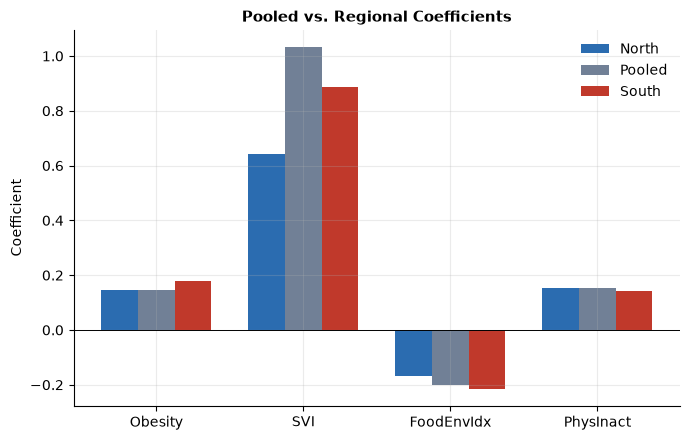

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
labels = ["Obesity", "SVI", "FoodEnvIdx", "PhysInact"]
x = np.arange(len(labels))
width = 0.25
ax.bar(x - width, [ols_north.beta[coef_table.index.get_loc(l)] for l in labels], width, label="North", color=C["blue"])
ax.bar(x, [pooled.beta[coef_table.index.get_loc(l)] for l in labels], width, label="Pooled", color=C["grey"])
ax.bar(x + width, [ols_south.beta[coef_table.index.get_loc(l)] for l in labels], width, label="South", color=C["red"])
ax.axhline(0, color="k", lw=0.7)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Coefficient")
ax.set_title("Pooled vs. Regional Coefficients")
ax.legend()
plt.tight_layout()
plt.show()

For every covariate shown, the pooled (grey) bar sits **between** the North and South estimates — exactly what
a single compromise value looks like. A county in the South, whose true `SVI` relationship is closer to 0.89,
is systematically under-predicted by a model using the pooled value of 1.03 whenever `SVI` is high; a county in
the North is over-predicted by the same amount in the other direction. Neither error shows up as a *spatially
autocorrelated residual* the way Chapter 3.2's diagnostics would catch (both halves' own residuals can still be
individually well-behaved) — it shows up as a form of **specification bias that is spatially structured but
invisible to Moran's I on the pooled residuals**, because it is smooth curvature in *how the relationship
itself* changes, not clustering in leftover *noise*.

***
## 7. The Bridge to Part 6

Splitting the data into two arbitrary halves is a blunt instrument — real geographic variation in a
relationship's strength is rarely a clean step function at one latitude, and choosing where to split is itself
an arbitrary, MAUP-flavoured decision (Part 2, Chapter 2.1). **Geographically weighted regression** (Part 6)
generalises the idea in this chapter to its natural conclusion: instead of two regressions (or one), fit a
*separate, smoothly varying* regression **centred at every location**, using a kernel to weight nearby
observations more heavily — recovering a continuous surface of local coefficients rather than one, two, or any
fixed number of discrete regimes.

The North/South split here is best understood as an existence proof — "yes, the relationship really does vary
enough to matter, and a formal test confirms it" — that motivates going to Part 6's fully local approach rather
than trying to guess the right number and shape of regional splits by hand. The joint comparison workflow that
puts OLS, SLM, SEM, and GWR side by side on the same diagnostic terms is Chapter 6.8.

***
## 8. Summary and Conclusions

This short chapter tested the one assumption every model in Chapters 3.2–3.5 shares, and found it fails.

### What we did

1. Stated explicitly that OLS, SLM, and SEM all assume one $\beta_k$ per covariate, shared by every county.
2. Split the 666 Atlantic counties at the median latitude and refit the same specification on each half:
   coefficients moved by 20–40% for several covariates, and `Urban` changed sign.
3. Ran a formal Chow test: F = 2.85, p = 0.004 — the pooled model's coefficients are statistically
   distinguishable from a model that lets the North and South differ.
4. Visualised the pooled coefficient as a compromise sitting between the two regional estimates for every
   covariate checked.
5. Connected this finding to Part 6: geographically weighted regression generalises the crude two-region split
   into a continuous, spatially varying coefficient surface.

### Practical takeaways

- A model can pass every diagnostic in Chapters 3.2–3.5 (clean residual Moran's I, significant coefficients,
  reasonable fit) and still hide a real, testable failure of the constant-coefficient assumption — the two are
  different kinds of misspecification, and only one of them shows up in a residual autocorrelation test.
- A quick regional split-and-Chow-test is a cheap, informative first check for whether a relationship's
  *strength*, not just its residuals, varies spatially — worth running before committing to any global model.
- Part 6 exists specifically because two or three arbitrary geographic splits are rarely the right way to
  capture this kind of variation.

### Next steps

**Chapter 3.7 (Code Skeleton and Exercises)** closes Part 3 with a compact, reusable code skeleton for the full
workflow (Chapters 3.2–3.5) and five solved exercises spanning every chapter in this Part.

***
## 9. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Fotheringham, A. S., Brunsdon, C. & Charlton, M. (2002). *Geographically Weighted Regression: The Analysis of Spatially Varying Relationships*. Wiley. | The full treatment this chapter previews; Part 6's primary reference |
| Chow, G. C. (1960). Tests of equality between sets of coefficients in two linear regressions. *Econometrica*, 28, 591–605. | Origin of the Chow test used in Section 5 |

### Key papers

| Paper | Contribution |
|---|---|
| Fotheringham, A. S., Brunsdon, C. & Charlton, M. (1998). Geographically weighted regression: a natural evolution of the expansion method for spatial data analysis. *Environment and Planning A*, 30, 1905–1927. | Foundational GWR paper, framing it as a generalisation of exactly the kind of regional-split test used here |
| Brunsdon, C., Fotheringham, A. S. & Charlton, M. (1996). Geographically weighted regression: a method for exploring spatial nonstationarity. *Geographical Analysis*, 28, 281–298. | Formal statistical tests for spatial nonstationarity in regression coefficients |

### In this library

| Object | Role |
|---|---|
| `spatialstats.regression.OLS` | Reused here to fit the regional sub-models |
| Part 6 | `spatialstats.gwmodel` — the continuous, kernel-weighted generalisation of this chapter's North/South split |
| Chapter 6.8 | The joint OLS/SLM/SEM/GWR comparison workflow this chapter's Section 7 references |